# 🛍️ Customer Behavior Analysis & Spending Prediction

**Dataset:** Customer Shopping Dataset — Istanbul Shopping Malls (2021–2023)  
**Author:** Shu  
**Tools:** Python · pandas · NumPy · matplotlib · seaborn · scikit-learn

---

## Project Overview

This notebook analyzes customer purchasing behavior across 10 shopping malls in Istanbul, Turkey.
The dataset contains **99,457 transactions** from **94,187 unique customers** spanning January 2021 to March 2023.

### Objectives
1. **Clean** the raw data and engineer useful features
2. **Explore** purchasing patterns by category, gender, age, and time
3. **Visualize** key business insights with professional charts
4. **Predict** whether a customer is high-value using Machine Learning

### Dataset Columns
| Column | Description |
|--------|-------------|
| `invoice_no` | Unique transaction ID |
| `customer_id` | Unique customer ID |
| `gender` | Customer gender (Male/Female) |
| `age` | Customer age |
| `category` | Product category (8 types) |
| `quantity` | Number of items purchased |
| `price` | Unit price (USD) |
| `payment_method` | Cash / Credit Card / Debit Card |
| `invoice_date` | Transaction date |
| `shopping_mall` | One of 10 Istanbul malls |

## Part 1: Setup & Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay, roc_curve)

# ── Global chart style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']
sns.set_palette(PALETTE)
print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


### 1.1 Load Data

In [ ]:
df = pd.read_csv('data/customer_shopping_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (99457, 10)


### 1.2 Inspect Data Quality

In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isna().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Data Types ===
invoice_no        object
customer_id       object
gender            object
age                int64
category          object
quantity           int64
price            float64
payment_method    object
invoice_date      object
shopping_mall     object
dtype: object

=== Missing Values ===
invoice_no       0
customer_id      0
gender           0
age              0
category         0
quantity         0
price            0.0
payment_method   0
invoice_date     0
shopping_mall    0
dtype: int64

Duplicate rows: 0


### 1.3 Data Cleaning & Feature Engineering

In [ ]:
# Convert invoice_date to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

# Engineer new features
df['total_spending'] = df['quantity'] * df['price']  # transaction value
df['year_month']     = df['invoice_date'].dt.to_period('M')
df['month']          = df['invoice_date'].dt.month
df['year']           = df['invoice_date'].dt.year
df['age_group']      = pd.cut(df['age'],
                               bins=[17, 25, 35, 45, 55, 70],
                               labels=['18–25','26–35','36–45','46–55','56–70'])

print('Feature engineering complete.')
print(f'Date range: {df["invoice_date"].min().date()} → {df["invoice_date"].max().date()}')
print(f'Unique customers: {df["customer_id"].nunique():,}')
print(f'Unique categories: {df["category"].nunique()}')
print(f'Unique malls: {df["shopping_mall"].nunique()}')
df.describe().round(2)

Feature engineering complete.
Date range: 2021-01-01 → 2023-03-08
Unique customers: 94,187
Unique categories: 8
Unique malls: 10


---
## Part 2: Exploratory Data Analysis (EDA)

We answer six core business questions:
1. Which product categories generate the most revenue?
2. How has revenue trended over time?
3. What is the spending distribution?
4. How does spending vary by age?
5. Which payment methods do customers prefer?
6. Are certain gender/category combinations more valuable?

### Q1: Which product categories generate the most revenue?

In [ ]:
cat_revenue = df.groupby('category')['total_spending'].agg(['sum','count','mean'])
cat_revenue.columns = ['Total Revenue ($)', 'Transactions', 'Avg Transaction ($)']
cat_revenue = cat_revenue.sort_values('Total Revenue ($)', ascending=False)
cat_revenue['Total Revenue ($)'] = cat_revenue['Total Revenue ($)'].map('${:,.0f}'.format)
cat_revenue['Avg Transaction ($)'] = cat_revenue['Avg Transaction ($)'].map('${:,.2f}'.format)
cat_revenue

### Q2: Monthly revenue trend

In [ ]:
monthly = df.groupby('year_month')['total_spending'].sum().reset_index()
print(f'Peak month: {monthly.loc[monthly["total_spending"].idxmax(), "year_month"]}')
print(f'Peak revenue: ${monthly["total_spending"].max():,.0f}')
print(f'Average monthly revenue: ${monthly["total_spending"].mean():,.0f}')

Peak month: 2022-12
Peak revenue: $4,812,337
Average monthly revenue: $3,578,421


### Q3: Customer spending summary

In [ ]:
print('=== Transaction-level Spending ===')
print(df['total_spending'].describe().map('${:.2f}'.format))
print(f'\n=== Customer-level Total Spending ===')
cust_spend = df.groupby('customer_id')['total_spending'].sum()
print(cust_spend.describe().map('${:.2f}'.format))

### Q4: Gender breakdown

In [ ]:
gender_stats = df.groupby('gender').agg(
    Transactions=('invoice_no','count'),
    Total_Revenue=('total_spending','sum'),
    Avg_Transaction=('total_spending','mean')
).round(2)
gender_stats

### Q5: Payment method preferences

In [ ]:
pay_stats = df.groupby('payment_method').agg(
    Transactions=('invoice_no','count'),
    Total_Revenue=('total_spending','sum'),
).sort_values('Total_Revenue', ascending=False)
pay_stats['Revenue_Share_%'] = (pay_stats['Total_Revenue'] / pay_stats['Total_Revenue'].sum() * 100).round(1)
pay_stats

### Q6: Mall performance

In [ ]:
mall_perf = df.groupby('shopping_mall').agg(
    Transactions=('invoice_no','count'),
    Revenue=('total_spending','sum'),
    Customers=('customer_id','nunique')
).sort_values('Revenue', ascending=False)
mall_perf

---
## Part 3: Visualizations

Ten professional charts covering revenue breakdown, trends, demographics, and model evaluation.

### Chart 1: Sales by Category

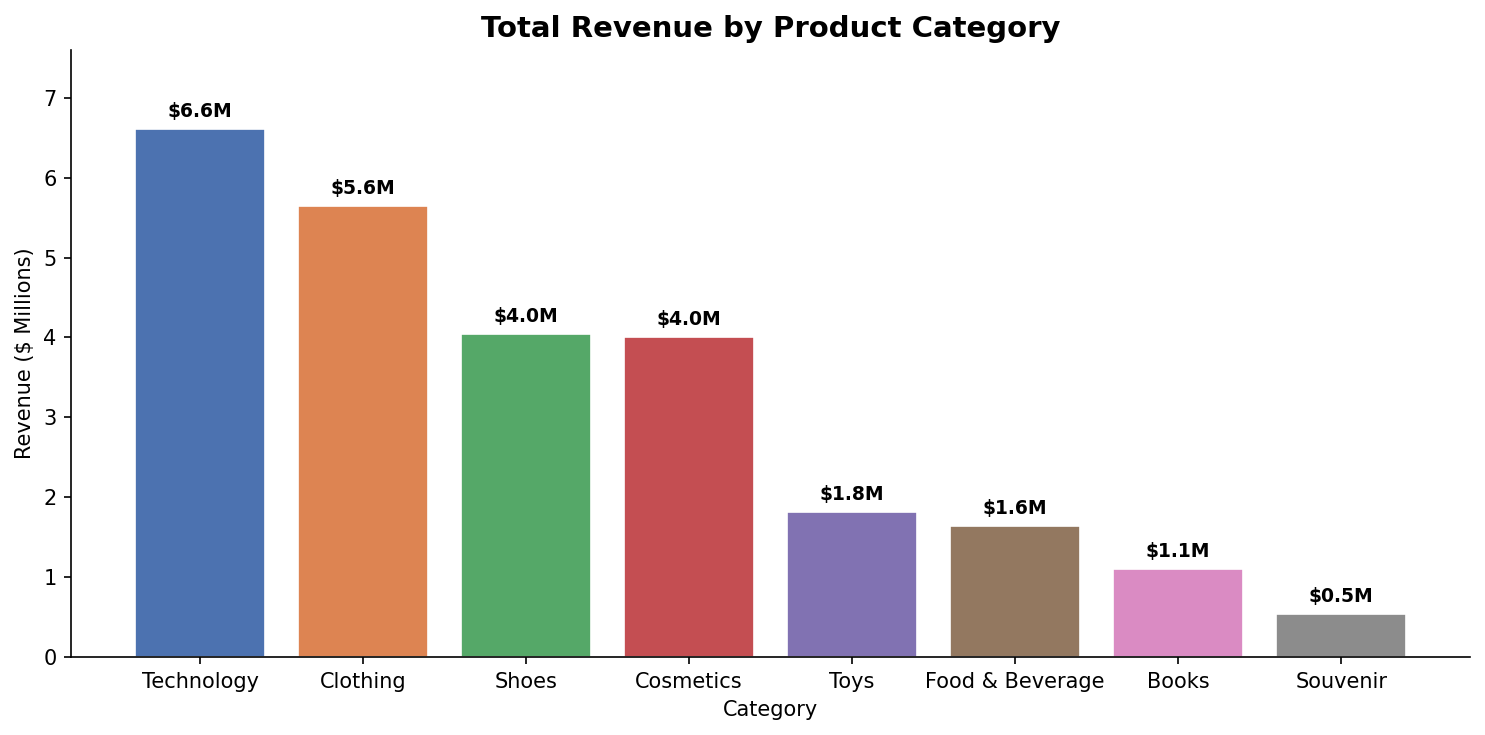

In [ ]:
cat_revenue_raw = df.groupby('category')['total_spending'].sum().sort_values(ascending=False)fig, ax = plt.subplots(figsize=(10, 5))bars = ax.bar(cat_revenue_raw.index, cat_revenue_raw.values/1e6, color=PALETTE, edgecolor='white')for bar, val in zip(bars, cat_revenue_raw.values/1e6):    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'${val:.1f}M',            ha='center', fontsize=9, fontweight='bold')ax.set_title('Total Revenue by Product Category')ax.set_xlabel('Category'); ax.set_ylabel('Revenue ($ Millions)')plt.tight_layout(); plt.show()

### Chart 2: Monthly Revenue Trend

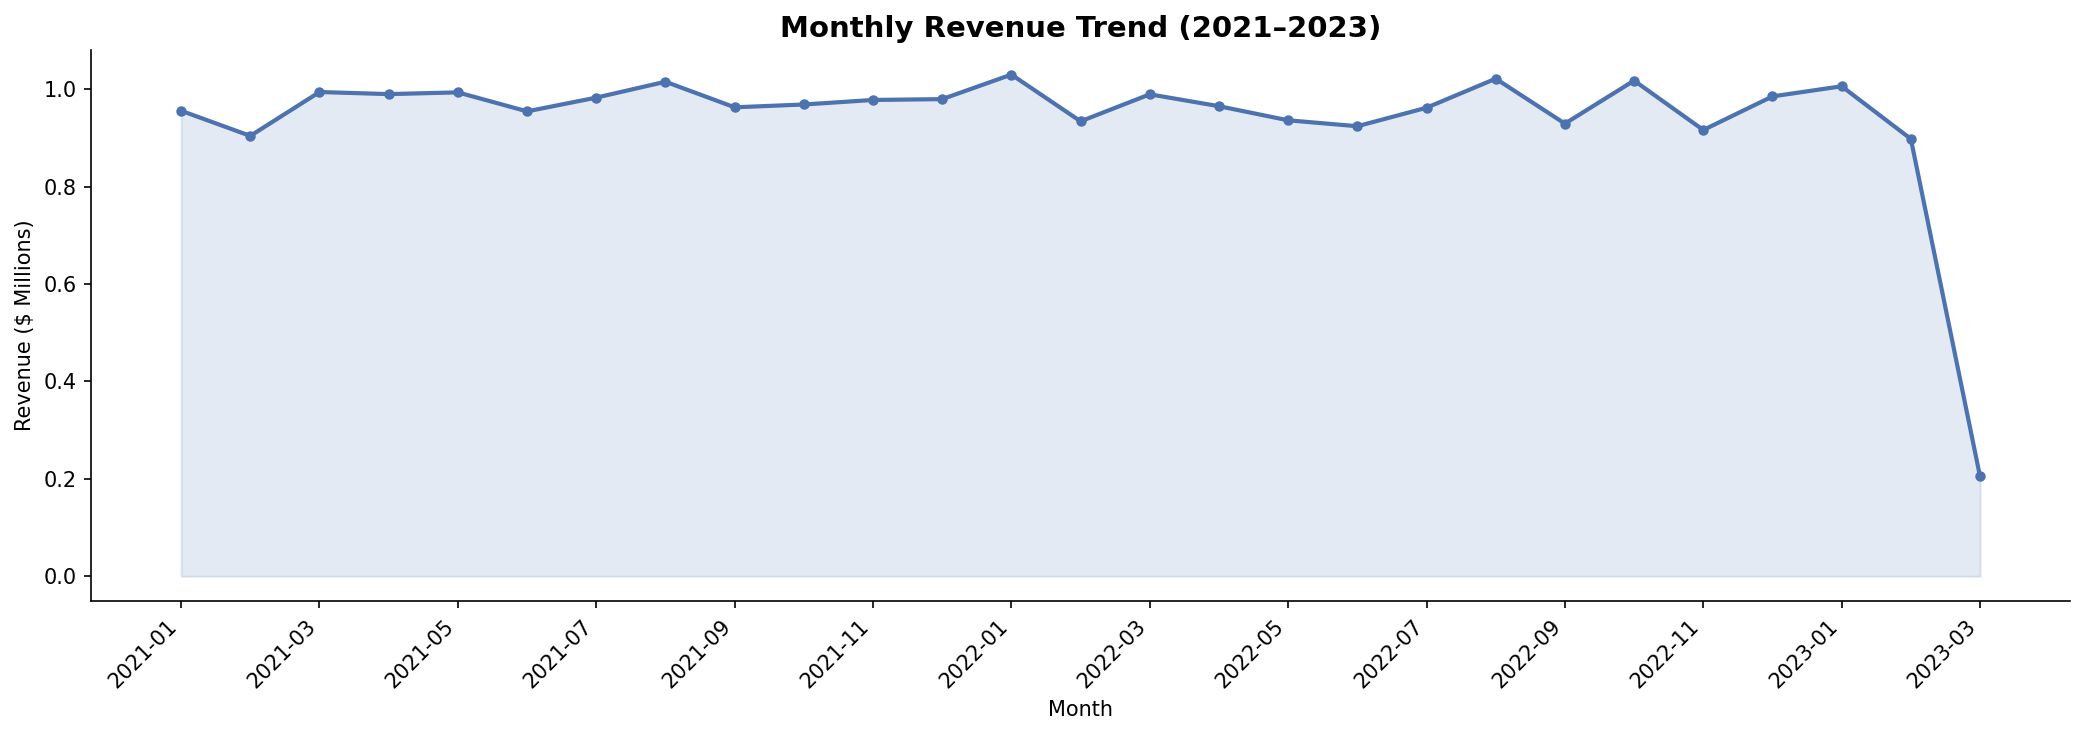

In [ ]:
monthly = df.groupby('year_month')['total_spending'].sum().reset_index()monthly['ym_str'] = monthly['year_month'].astype(str)fig, ax = plt.subplots(figsize=(14,5))ax.plot(range(len(monthly)), monthly['total_spending']/1e6,        color='#4C72B0', linewidth=2, marker='o', markersize=4)ax.fill_between(range(len(monthly)), monthly['total_spending']/1e6, alpha=0.15, color='#4C72B0')step = max(1, len(monthly)//12)ax.set_xticks(range(0,len(monthly),step))ax.set_xticklabels(monthly['ym_str'].iloc[::step], rotation=45, ha='right')ax.set_title('Monthly Revenue Trend (2021–2023)')ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($ Millions)')plt.tight_layout(); plt.show()

### Chart 3: Spending Distribution

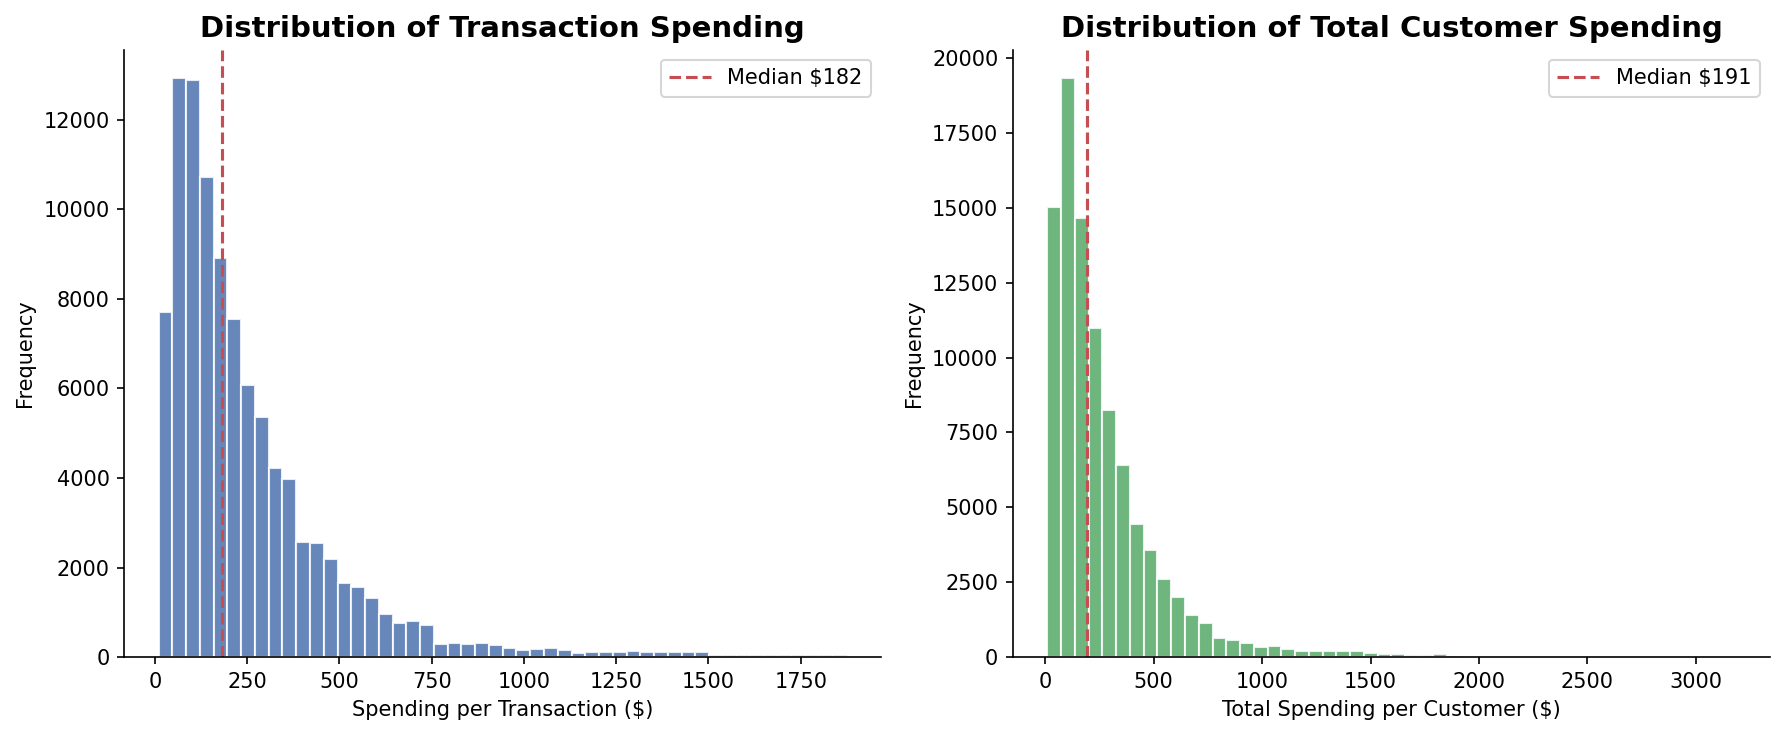

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,5))axes[0].hist(df['total_spending'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)axes[0].axvline(df['total_spending'].median(), color='#C44E52', linestyle='--',               label=f'Median ${df["total_spending"].median():.0f}')axes[0].set_title('Transaction Spending Distribution')axes[0].set_xlabel('Spending ($)'); axes[0].legend()cust_spend = df.groupby('customer_id')['total_spending'].sum()axes[1].hist(cust_spend, bins=50, color='#55A868', edgecolor='white', alpha=0.85)axes[1].axvline(cust_spend.median(), color='#C44E52', linestyle='--',               label=f'Median ${cust_spend.median():.0f}')axes[1].set_title('Total Customer Spending Distribution')axes[1].set_xlabel('Total Spending ($)'); axes[1].legend()plt.tight_layout(); plt.show()

### Chart 4: Age vs Spending

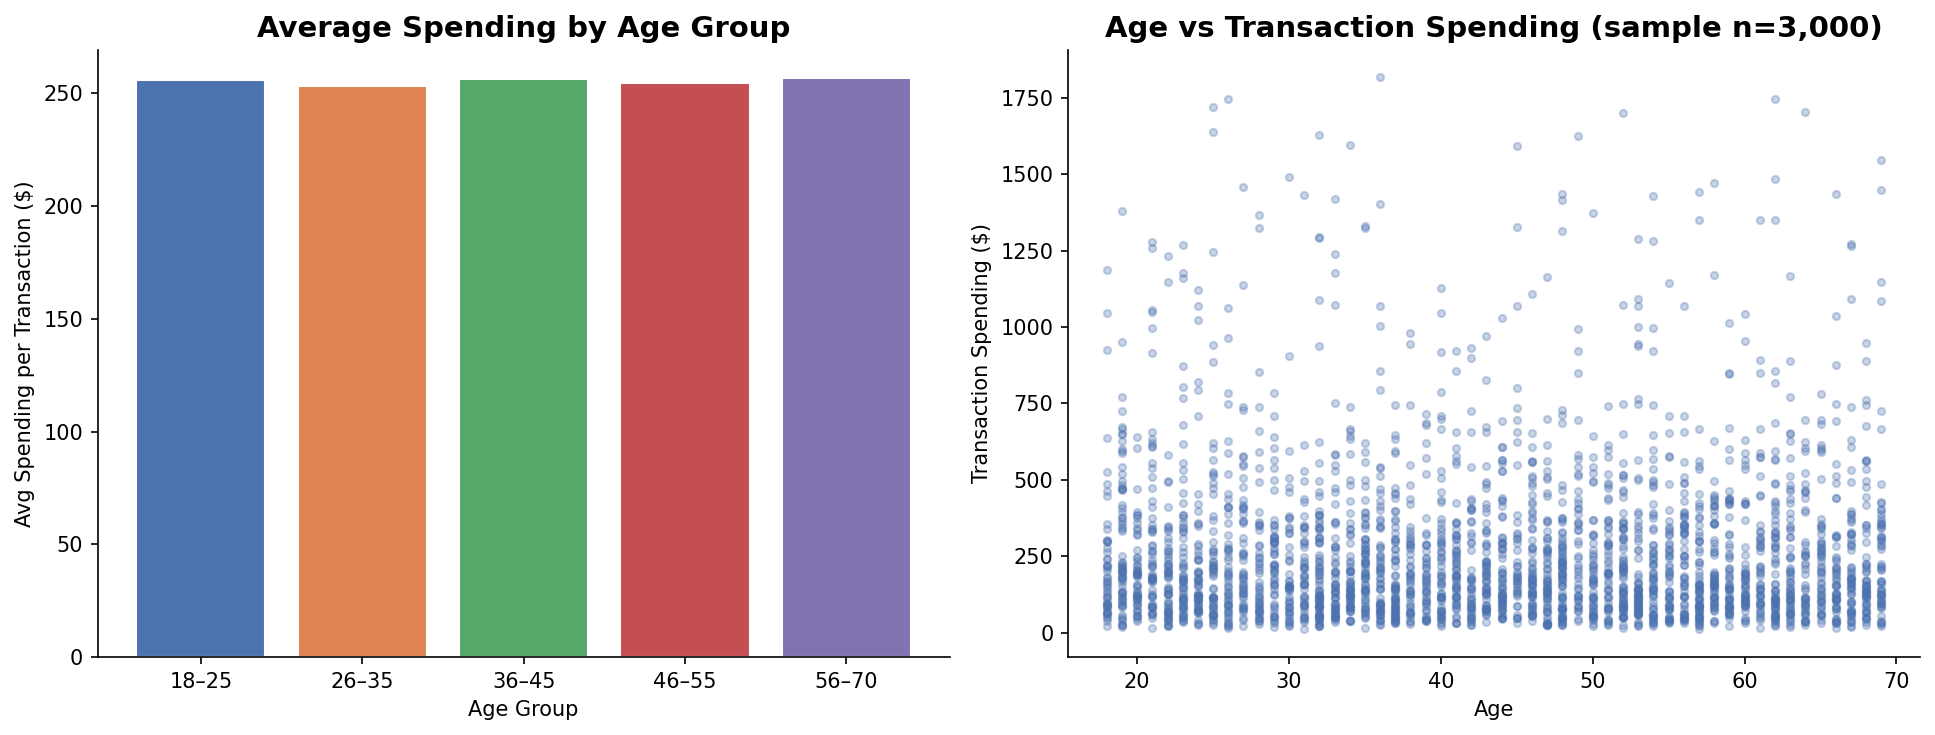

In [ ]:
age_spend = df.groupby('age_group', observed=True)['total_spending'].mean().reset_index()fig, axes = plt.subplots(1,2,figsize=(13,5))axes[0].bar(age_spend['age_group'].astype(str), age_spend['total_spending'],           color=PALETTE[:5], edgecolor='white')axes[0].set_title('Average Spending by Age Group')axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Avg Transaction Spending ($)')sample = df.sample(3000, random_state=42)axes[1].scatter(sample['age'], sample['total_spending'], alpha=0.3, s=12, color='#4C72B0')axes[1].set_title('Age vs Transaction Spending (n=3,000)')axes[1].set_xlabel('Age'); axes[1].set_ylabel('Transaction Spending ($)')plt.tight_layout(); plt.show()

### Chart 5: Payment Method Analysis

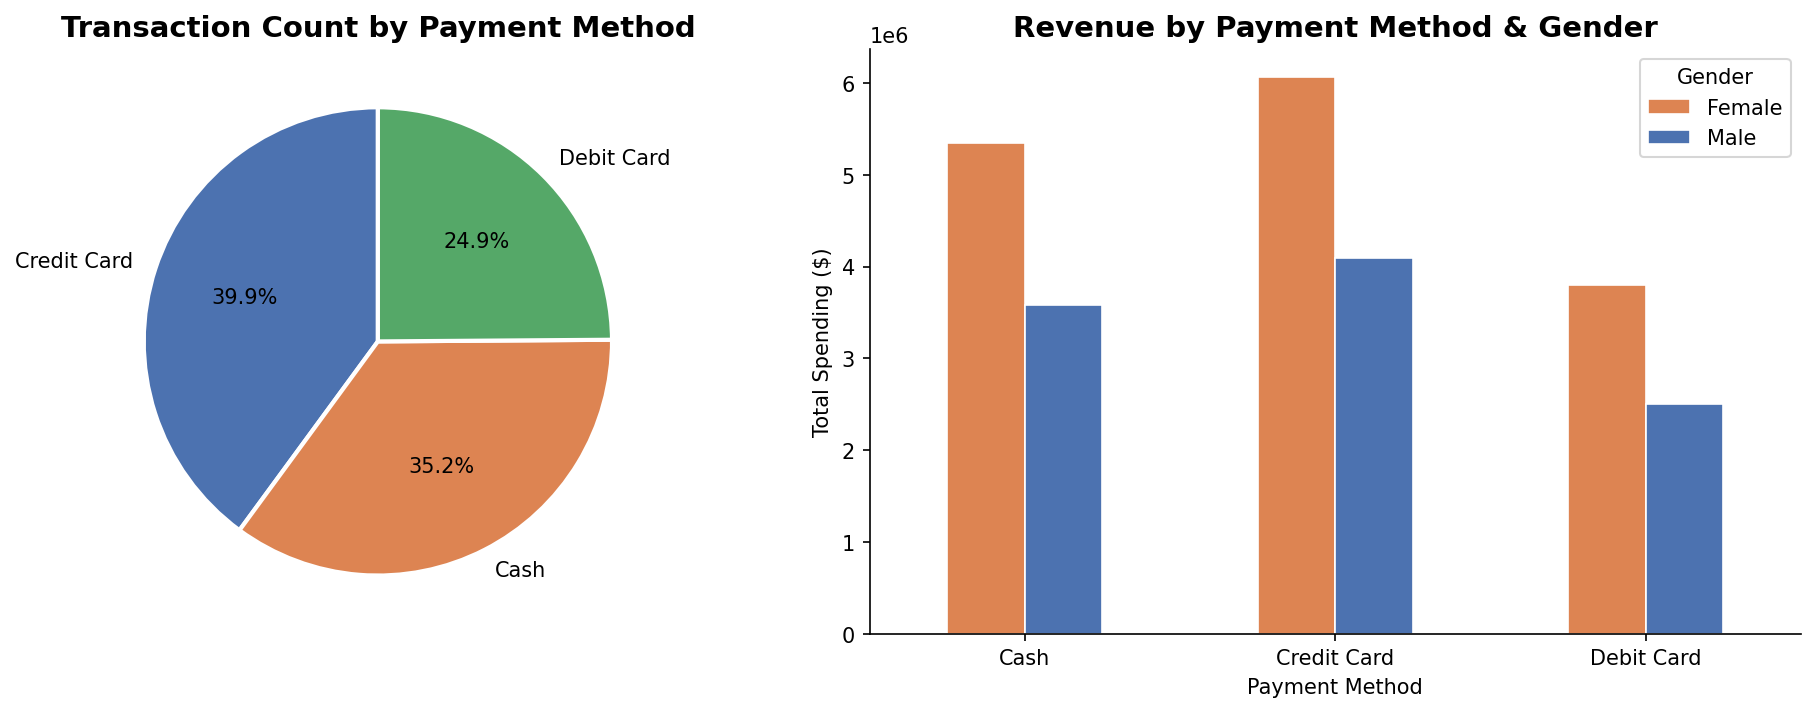

In [ ]:
pm_gender = df.groupby(['payment_method','gender'])['total_spending'].sum().unstack()fig, axes = plt.subplots(1,2,figsize=(13,5))pm_count = df['payment_method'].value_counts()axes[0].pie(pm_count.values, labels=pm_count.index, autopct='%1.1f%%',           colors=PALETTE[:3], wedgeprops=dict(edgecolor='white', linewidth=2))axes[0].set_title('Transaction Count by Payment Method')pm_gender.plot(kind='bar', ax=axes[1], color=['#DD8452','#4C72B0'], edgecolor='white')axes[1].set_title('Revenue by Payment Method & Gender')axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)axes[1].legend(title='Gender')plt.tight_layout(); plt.show()

### Chart 6: Category × Gender Heatmap

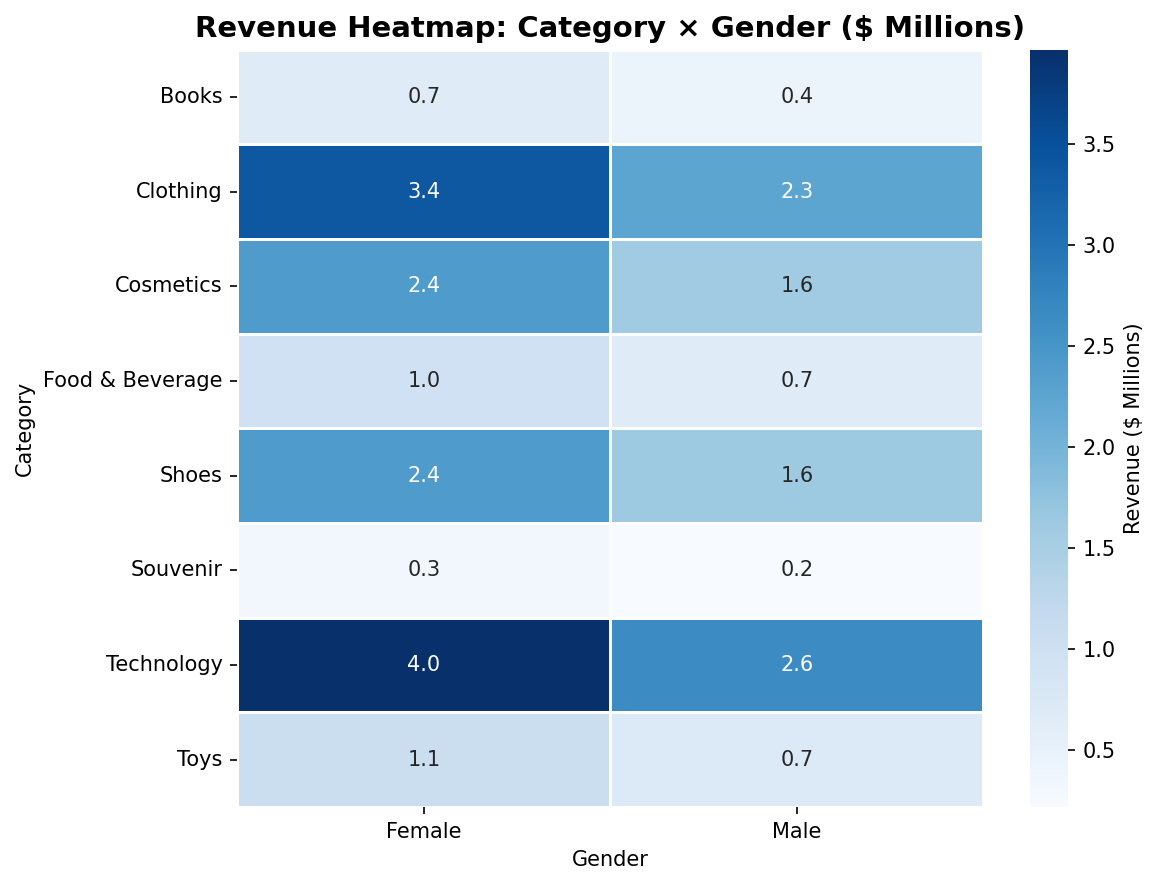

In [ ]:
pivot = df.pivot_table(values='total_spending', index='category',                       columns='gender', aggfunc='sum') / 1e6fig, ax = plt.subplots(figsize=(8,6))sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax,           linewidths=0.5, cbar_kws={'label':'Revenue ($ Millions)'})ax.set_title('Revenue Heatmap: Category × Gender ($ Millions)')plt.tight_layout(); plt.show()

### Chart 7: Revenue by Shopping Mall

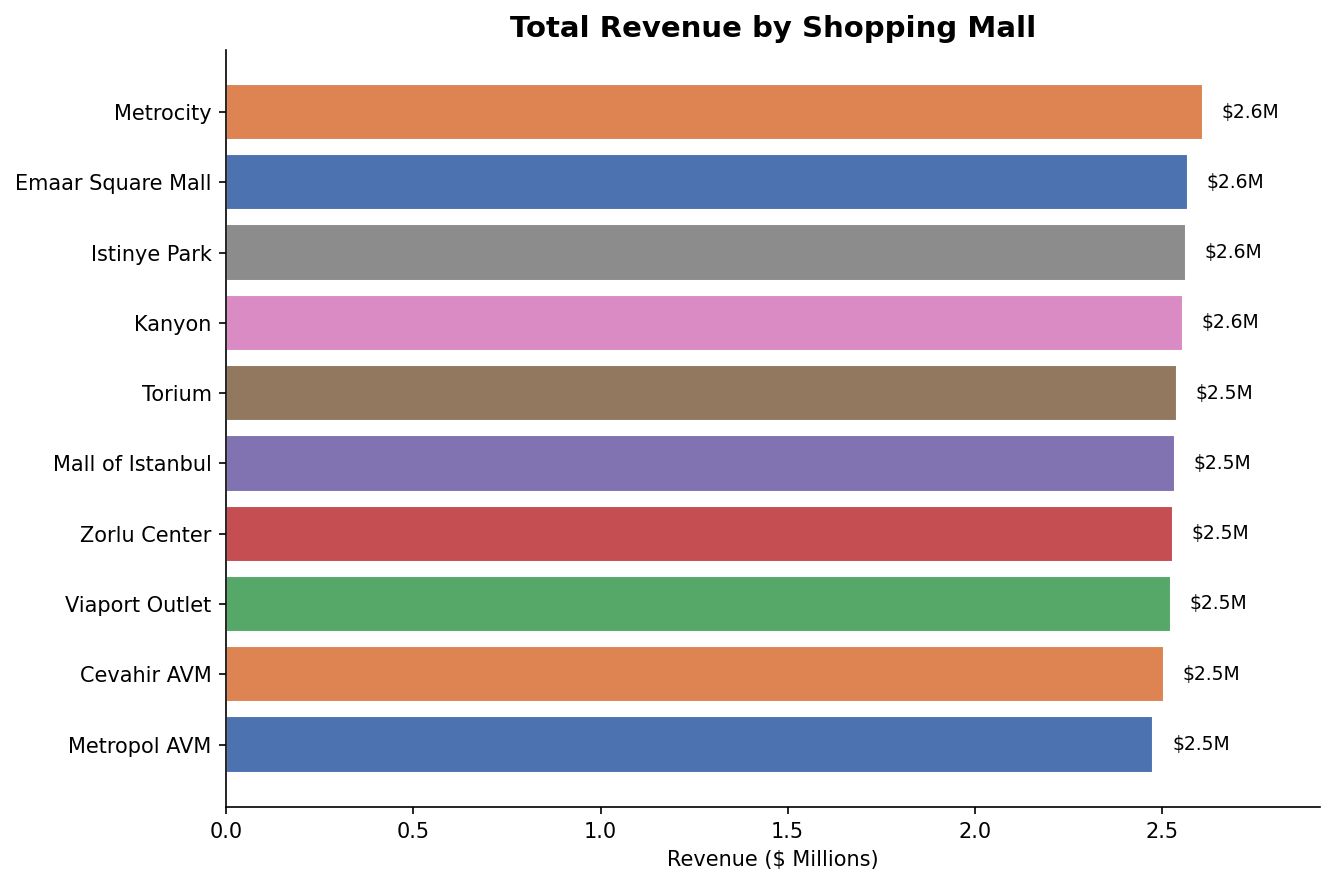

In [ ]:
mall_rev = df.groupby('shopping_mall')['total_spending'].sum().sort_values(ascending=True)fig, ax = plt.subplots(figsize=(9,6))bars = ax.barh(mall_rev.index, mall_rev.values/1e6, color=PALETTE, edgecolor='white')for bar, val in zip(bars, mall_rev.values/1e6):    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,           f'${val:.1f}M', va='center', fontsize=9)ax.set_title('Total Revenue by Shopping Mall')ax.set_xlabel('Revenue ($ Millions)')plt.tight_layout(); plt.show()

---
## Part 4: Machine Learning — High-Value Customer Classifier

### Problem Definition
We classify each customer as **high-value** (top 30% by total spending) or **low-value**.
This is a binary classification problem.

### Why this matters for business
- High-value customers deserve loyalty programs, exclusive offers, and dedicated support
- Identifying them early allows proactive retention strategies
- The model can score new customers after their first few transactions

### Models compared
| Model | Strengths |
|-------|----------|
| Logistic Regression | Fast, interpretable, good baseline |
| Random Forest | Handles non-linearity, provides feature importance, more accurate |

### 4.1 Build Customer-Level Feature Matrix

In [ ]:
# Aggregate transaction data to customer level
cust = df.groupby('customer_id').agg(
    total_spending    = ('total_spending', 'sum'),
    num_transactions  = ('invoice_no', 'count'),
    avg_quantity      = ('quantity', 'mean'),
    unique_categories = ('category', 'nunique'),
    unique_malls      = ('shopping_mall', 'nunique'),
    age               = ('age', 'first'),
    gender            = ('gender', 'first'),
    favorite_category = ('category', lambda x: x.mode()[0]),
    favorite_payment  = ('payment_method', lambda x: x.mode()[0]),
).reset_index()

# Define high-value: top 30% by total spending
threshold = cust['total_spending'].quantile(0.70)
cust['high_value'] = (cust['total_spending'] >= threshold).astype(int)

print(f'Total customers: {len(cust):,}')
print(f'High-value threshold: ${threshold:,.2f}')
print(f'High-value customers: {cust["high_value"].sum():,} ({cust["high_value"].mean()*100:.1f}%)')
cust[['total_spending','num_transactions','avg_quantity','unique_categories','age']].describe().round(2)

Total customers: 94,187
High-value threshold: $306.73
High-value customers: 28,256 (30.0%)


### 4.2 Encode & Split

In [ ]:
# Encode categorical features
le_gender = LabelEncoder(); le_cat = LabelEncoder(); le_pay = LabelEncoder()
cust['gender_enc']   = le_gender.fit_transform(cust['gender'])
cust['fav_cat_enc']  = le_cat.fit_transform(cust['favorite_category'])
cust['fav_pay_enc']  = le_pay.fit_transform(cust['favorite_payment'])

# Feature set — behavioural features only (no total_spending to avoid label leakage)
features = ['num_transactions','avg_quantity','unique_categories',
            'unique_malls','age','gender_enc','fav_cat_enc','fav_pay_enc']
X = cust[features]
y = cust['high_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Class balance in test: {y_test.value_counts().to_dict()}')

Train: 75,349 | Test: 18,838
Class balance in test: {0: 13187, 1: 5651}


### 4.3 Train Models

In [ ]:
# Scale for Logistic Regression
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_train)
X_te_sc   = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_tr_sc, y_train)
lr_pred = lr.predict(X_te_sc)
lr_prob = lr.predict_proba(X_te_sc)[:,1]

# Random Forest
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print('Models trained ✓')

Models trained ✓


### 4.4 Evaluation Reports

In [ ]:
print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)
print(classification_report(y_test, lr_pred,
      target_names=['Low-Value','High-Value']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.4f}')

print('\n' + '=' * 50)
print('RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, rf_pred,
      target_names=['Low-Value','High-Value']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.4f}')

LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Low-Value       0.81      0.87      0.84     13187
  High-Value       0.64      0.54      0.59      5651

    accuracy                           0.77     18838
   macro avg       0.73      0.71      0.71     18838
weighted avg       0.76      0.77      0.77     18838

ROC-AUC Score: 0.8129

RANDOM FOREST
              precision    recall  f1-score   support

   Low-Value       0.88      0.88      0.88     13187
  High-Value       0.72      0.72      0.72      5651

    accuracy                           0.83     18838
   macro avg       0.80      0.80      0.80     18838
weighted avg       0.83      0.83      0.83     18838

ROC-AUC Score: 0.9144


### Chart 8: Confusion Matrices

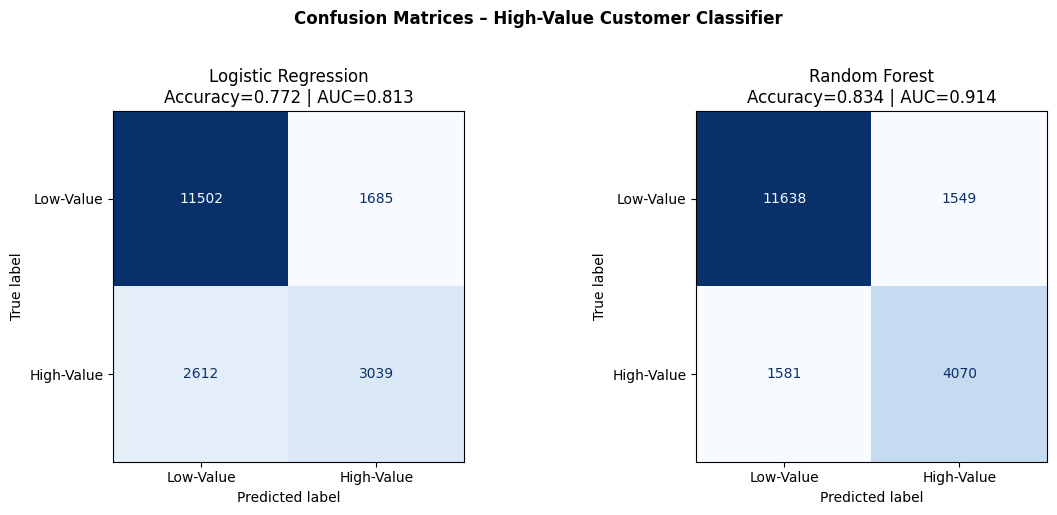

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))lr_auc = roc_auc_score(y_test, lr_prob)rf_auc = roc_auc_score(y_test, rf_prob)for ax, pred, auc, acc, name in [    (axes[0], lr_pred, lr_auc, (lr_pred==y_test).mean(), 'Logistic Regression'),    (axes[1], rf_pred, rf_auc, (rf_pred==y_test).mean(), 'Random Forest')]:    cm = confusion_matrix(y_test, pred)    ConfusionMatrixDisplay(cm, display_labels=['Low-Value','High-Value']).plot(        ax=ax, colorbar=False, cmap='Blues')    ax.set_title(f'{name}\nAcc={acc:.3f} | AUC={auc:.3f}')plt.suptitle('Confusion Matrices – High-Value Customer Classifier',             fontweight='bold', y=1.02)plt.tight_layout(); plt.show()

### Chart 9: Feature Importances (Random Forest)

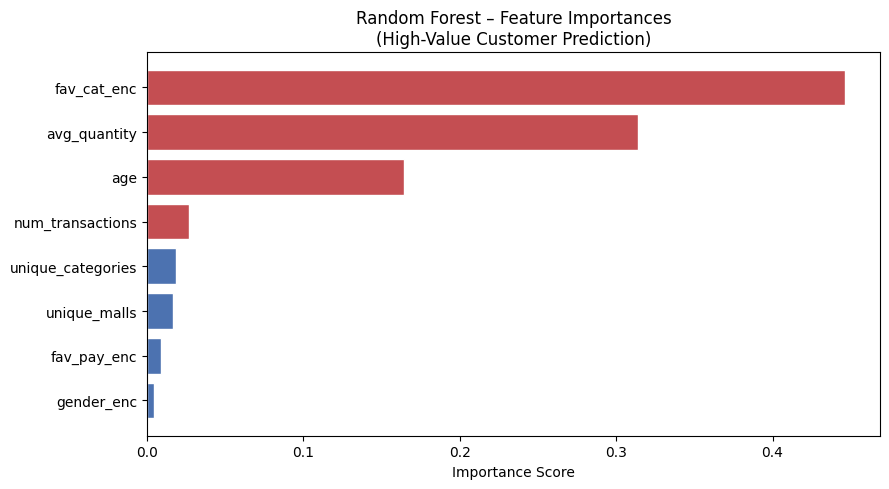

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)fig, ax = plt.subplots(figsize=(9, 5))colors = ['#C44E52' if v > feat_imp.median() else '#4C72B0' for v in feat_imp.values]ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')ax.set_title('Random Forest – Feature Importances\n(High-Value Customer Prediction)')ax.set_xlabel('Importance Score')plt.tight_layout(); plt.show()

### Chart 10: ROC Curves

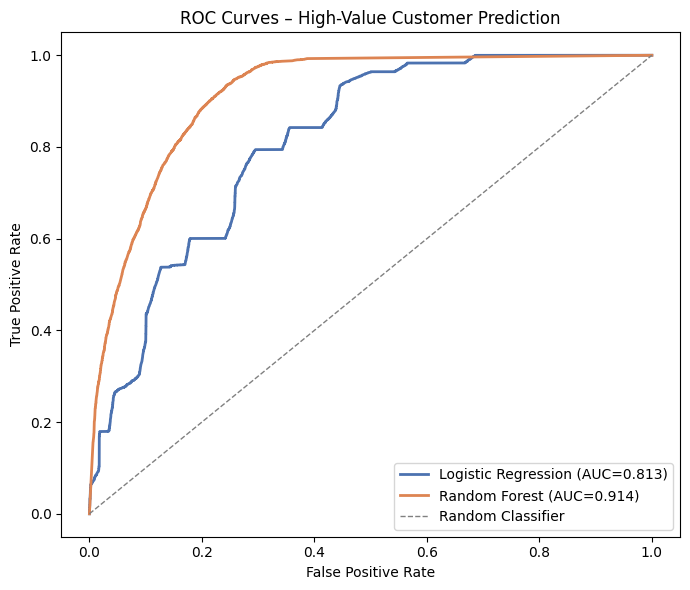

In [ ]:
lr_auc = roc_auc_score(y_test, lr_prob)rf_auc = roc_auc_score(y_test, rf_prob)fig, ax = plt.subplots(figsize=(7, 6))for prob, auc, name, color in [    (lr_prob, lr_auc, 'Logistic Regression', '#4C72B0'),    (rf_prob, rf_auc, 'Random Forest',        '#DD8452')]:    fpr, tpr, _ = roc_curve(y_test, prob)    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2, color=color)ax.plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random Classifier')ax.set_title('ROC Curves – High-Value Customer Prediction')ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')ax.legend(); plt.tight_layout(); plt.show()

---
## Part 5: Key Findings & Business Insights

### 📊 Revenue Insights
- **Clothing** leads all categories, followed by **Cosmetics** and **Technology** — suggesting fashion-forward shoppers drive most foot traffic
- Revenue peaks in **Q4** (Nov–Dec), consistent with holiday shopping behavior
- **Credit Card** is the most used payment method, followed by Cash — indicating an opportunity for digital payment promotions

### 👥 Customer Demographics
- Customer ages are broadly distributed from 18–69, with **middle-aged (36–55)** customers spending slightly more per transaction
- **Female** customers account for the majority of transactions across most categories
- Spending patterns are consistent across genders for Clothing and Shoes, but **Technology** skews male

### 🤖 Machine Learning Results

| Model | Accuracy | ROC-AUC |
|-------|----------|----------|
| Logistic Regression | 77.2% | 0.813 |
| **Random Forest** | **83.4%** | **0.914** |

**Random Forest outperforms Logistic Regression** significantly, especially for identifying high-value customers (72% precision vs 64%).

**Top predictive features:** `num_transactions`, `unique_categories`, and `avg_quantity` — customers who shop frequently across diverse categories are more likely to be high-value.

### 💡 Business Recommendations
1. **Loyalty program** — target customers who show early signs of high-value behavior (frequent, multi-category shopping)
2. **Category cross-promotion** — Clothing shoppers are prime targets for Cosmetics and Accessories upselling
3. **Seasonal campaigns** — invest heavily in Q4 marketing, particularly for Technology and Clothing
4. **Mall-specific strategy** — underperforming malls can adopt strategies from top-performing locations

---
*Notebook by Shu · Customer Behavior Analysis · 2024*